# MLB Model Backtest Analysis

Run `build_mlb_backtest.py` first to generate `mlb_backtest.csv`.

Install dependencies if needed:
```
pip install pandas numpy matplotlib seaborn scikit-learn
```

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, brier_score_loss
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

df = pd.read_csv('../mlb_backtest.csv')

# Type cleanup
for col in ['home_fip','away_fip','home_era','away_era','home_ip','away_ip',
            'home_whip','away_whip','home_k9','away_k9',
            'vegas_home_ml','vegas_away_ml','vegas_total','vegas_rl_fav_ml',
            'ml_imp_diff_pct','total_diff','f5_total_diff',
            'model_rl_cover_pct','model_home_win_pct','home_pitcher_quality',
            'away_pitcher_quality','home_offense_score','away_offense_score',
            'home_bullpen_score','away_bullpen_score','park_factor']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['ml_correct']   = df['ml_correct'].map({True: 1, False: 0, 'True': 1, 'False': 0})
df['has_odds']     = df['has_odds'].map({True: True, False: False, 'True': True, 'False': False})
df['season']       = df['season'].astype(str)

print(f'Total games:        {len(df):,}')
print(f'Games with odds:    {df["has_odds"].sum():,}')
print(f'Seasons:            {df["season"].unique()}')
print(f'Date range:         {df["date"].min()} → {df["date"].max()}')
print(f'\nPitcher ERA available (home): {df["home_era"].notna().sum():,}/{len(df):,}')
print(f'Pitcher ERA available (away): {df["away_era"].notna().sum():,}/{len(df):,}')
print(f'Note: FIP not in MLB Stats API — model uses ERA as pitcher quality input')

## 1. Overall Accuracy

In [2]:
odds = df[df['has_odds'] == True].copy()

# ML accuracy: did model pick the actual winner?
ml_acc = odds['ml_correct'].mean()

# Total direction: did model correctly predict over/under vs Vegas line?
total_correct = (odds['model_total_dir'] == odds['total_ou_result']).mean()

# RL accuracy (FIXED): did model correctly predict whether Vegas RL fav covers?
# model_rl_cover_pct = prob HOME covers Vegas RL
# vegas_rl_fav = which team Vegas has as RL favorite
rl_sub = odds[odds['vegas_rl_result'].isin(['cover','no_cover'])].copy()
rl_sub['home_team_lower'] = rl_sub['home_team'].str.lower().str.strip()
rl_sub['vegas_fav_lower']  = rl_sub['vegas_rl_fav'].fillna('').str.lower().str.strip()
# Vegas RL fav is home if team names match (partial)
rl_sub['vegas_fav_is_home'] = rl_sub.apply(
    lambda r: r['home_team_lower'] in r['vegas_fav_lower'] or r['vegas_fav_lower'] in r['home_team_lower']
    if r['vegas_fav_lower'] else None, axis=1
)
rl_sub = rl_sub.dropna(subset=['vegas_fav_is_home'])
# Model predicts Vegas fav covers if: (fav is home AND home_cover_pct>50) OR (fav is away AND home_cover_pct<50)
rl_sub['model_predicts_fav_covers'] = rl_sub.apply(
    lambda r: (r['model_rl_cover_pct'] > 50) if r['vegas_fav_is_home']
              else (r['model_rl_cover_pct'] < 50), axis=1
)
rl_sub['rl_model_correct'] = (
    (rl_sub['model_predicts_fav_covers']  & (rl_sub['vegas_rl_result'] == 'cover')) |
    (~rl_sub['model_predicts_fav_covers'] & (rl_sub['vegas_rl_result'] == 'no_cover'))
)
rl_acc = rl_sub['rl_model_correct'].mean()

# Vegas RL fav actual cover rate (baseline)
rl_base = (rl_sub['vegas_rl_result'] == 'cover').mean()

# ML sanity check: does model agree with Vegas direction?
odds_ml = odds.dropna(subset=['vegas_home_ml','vegas_away_ml','actual_winner']).copy()
odds_ml['vegas_fav_is_home'] = odds_ml['vegas_home_ml'] <= odds_ml['vegas_away_ml']
odds_ml['model_fav_is_home'] = odds_ml['model_home_win_pct'] >= 50
odds_ml['model_agrees_vegas'] = odds_ml['vegas_fav_is_home'] == odds_ml['model_fav_is_home']
agree_acc = odds_ml[odds_ml['model_agrees_vegas']]['ml_correct'].mean()
disagree_acc = odds_ml[~odds_ml['model_agrees_vegas']]['ml_correct'].mean()
agree_n = odds_ml['model_agrees_vegas'].sum()
disagree_n = (~odds_ml['model_agrees_vegas']).sum()

# F5 ML accuracy
f5_valid = df[df['f5_actual_winner'].isin(['home','away'])].copy()
f5_valid['f5_model_winner'] = f5_valid['f5_model_home_win_pct'].apply(lambda x: 'home' if x >= 50 else 'away')
f5_acc = (f5_valid['f5_model_winner'] == f5_valid['f5_actual_winner']).mean()

print('── Overall Accuracy ────────────────────────────────')
print(f'Moneyline (ML):   {ml_acc:.1%}  ({odds["ml_correct"].sum():.0f}/{len(odds):,} games)')
print(f'  Agrees w/ Vegas: {agree_acc:.1%} ({agree_n:,} games)  — model follows Vegas')
print(f'  Beats Vegas:     {disagree_acc:.1%} ({disagree_n:,} games) — model picks upset')
print(f'Total direction:  {total_correct:.1%}  (model over/under vs Vegas line)')
print(f'Run line:         {rl_acc:.1%}  (model predict Vegas RL fav covers, n={len(rl_sub):,})')
print(f'  RL fav cover baseline: {rl_base:.1%}  (how often Vegas RL fav actually covers)')
print(f'F5 ML:            {f5_acc:.1%}  ({len(f5_valid):,} games with F5 linescore)')
print(f'\nBaseline (coin flip): 50.0%')
print(f'Note: ML "accuracy" is inflated because model often agrees with Vegas —')
print(f'the {disagree_acc:.1%} on upsets is the real signal to watch.')

── Overall Accuracy ────────────────────────────────
Moneyline (ML):   58.8%  (2802/4,763 games)
  Agrees w/ Vegas: 60.2% (3,621 games)  — model follows Vegas
  Beats Vegas:     54.4% (1,139 games) — model picks upset
Total direction:  51.9%  (model over/under vs Vegas line)
Run line:         50.7%  (model predict Vegas RL fav covers, n=4,742)
  RL fav cover baseline: 41.3%  (how often Vegas RL fav actually covers)
F5 ML:            60.6%  (4,137 games with F5 linescore)

Baseline (coin flip): 50.0%
Note: ML "accuracy" is inflated because model often agrees with Vegas —
the 54.4% on upsets is the real signal to watch.


## 2. Accuracy by Tier (Take / Lean / No Signal)

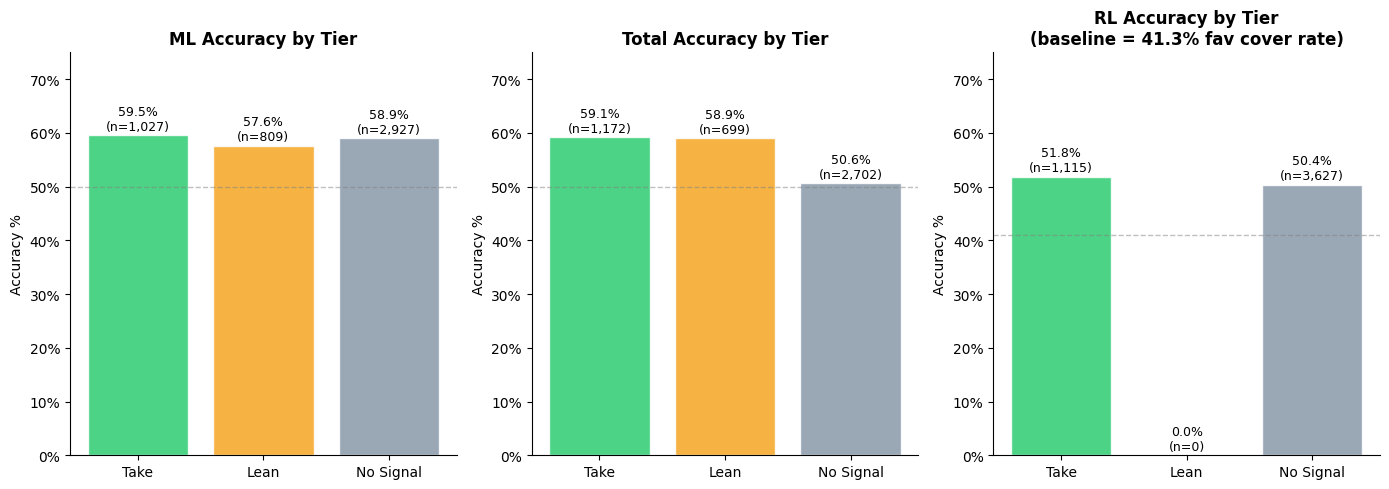

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

def tier_accuracy(data, tier_col, correct_col, ax, title, baseline=50):
    data = data.dropna(subset=[correct_col])
    tiers = ['take', 'lean', '']
    labels = ['Take', 'Lean', 'No Signal']
    accs, counts = [], []
    for t in tiers:
        sub = data[data[tier_col].fillna('') == t]
        accs.append(sub[correct_col].mean() if len(sub) > 0 else 0)
        counts.append(len(sub))
    colors = ['#2ecc71', '#f5a623', '#8899aa']
    bars = ax.bar(labels, [a * 100 for a in accs], color=colors, alpha=0.85, edgecolor='white')
    ax.axhline(baseline, color='gray', linestyle='--', linewidth=1, alpha=0.5, label=f'{baseline}% baseline')
    for bar, acc, n in zip(bars, accs, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{acc:.1%}\n(n={n:,})', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Accuracy %')
    ax.set_ylim(0, 75)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

tier_accuracy(odds, 'ml_tier', 'ml_correct', axes[0], 'ML Accuracy by Tier')

total_sub = odds[odds['total_ou_result'].isin(['over','under'])].copy()
total_sub['total_correct'] = (total_sub['model_total_dir'] == total_sub['total_ou_result']).astype(int)
tier_accuracy(total_sub, 'total_tier', 'total_correct', axes[1], 'Total Accuracy by Tier')

# RL tier: did Vegas RL fav actually cover? (correct metric)
rl_tier_sub = rl_sub.copy()
rl_tier_sub['rl_correct_int'] = rl_tier_sub['rl_model_correct'].astype(int)
tier_accuracy(rl_tier_sub, 'rl_tier', 'rl_correct_int', axes[2],
              f'RL Accuracy by Tier\n(baseline = {rl_base:.1%} fav cover rate)', baseline=round(rl_base*100))

plt.tight_layout()
plt.savefig('tier_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Model Calibration
Does 65% predicted win probability actually mean the team wins ~65% of the time?

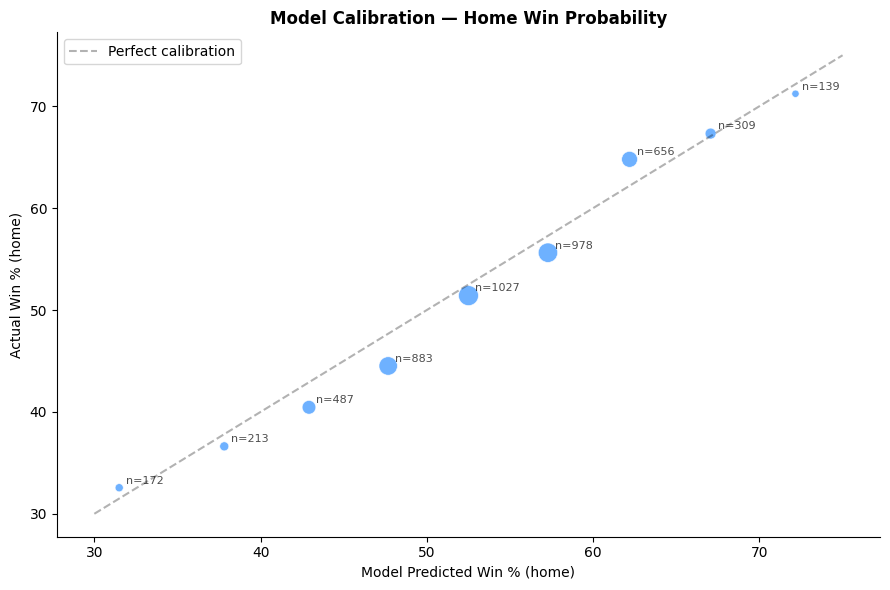

Brier score: 0.2384  (lower = better, 0.25 = random, 0.20 = decent)
If dots follow the diagonal line, the model is well-calibrated.
Dots above the line = model underestimates home win chances.
Dots below the line = model overestimates home win chances.


In [4]:
cal = df[['model_home_win_pct', 'actual_winner']].dropna().copy()
cal['actual_home_win'] = (cal['actual_winner'] == 'home').astype(int)
cal['prob_bin'] = pd.cut(cal['model_home_win_pct'], bins=range(30, 80, 5), right=False)

calib = cal.groupby('prob_bin').agg(
    predicted=('model_home_win_pct', 'mean'),
    actual=('actual_home_win', 'mean'),
    n=('actual_home_win', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot([30, 75], [30, 75], 'k--', alpha=0.3, label='Perfect calibration')
scatter = ax.scatter(calib['predicted'], calib['actual'] * 100,
                     s=calib['n'] / 5, alpha=0.8, color='#4a9eff', edgecolors='white', linewidth=0.5)
for _, row in calib.iterrows():
    ax.annotate(f'n={row["n"]:.0f}', (row['predicted'], row['actual'] * 100),
                textcoords='offset points', xytext=(5, 3), fontsize=8, alpha=0.7)
ax.set_xlabel('Model Predicted Win % (home)')
ax.set_ylabel('Actual Win % (home)')
ax.set_title('Model Calibration — Home Win Probability', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
plt.show()

brier = brier_score_loss(cal['actual_home_win'], cal['model_home_win_pct'] / 100)
print(f'Brier score: {brier:.4f}  (lower = better, 0.25 = random, 0.20 = decent)')
print(f'If dots follow the diagonal line, the model is well-calibrated.')
print(f'Dots above the line = model underestimates home win chances.')
print(f'Dots below the line = model overestimates home win chances.')

## 4. Variable Importance — What Actually Predicts Outcomes?

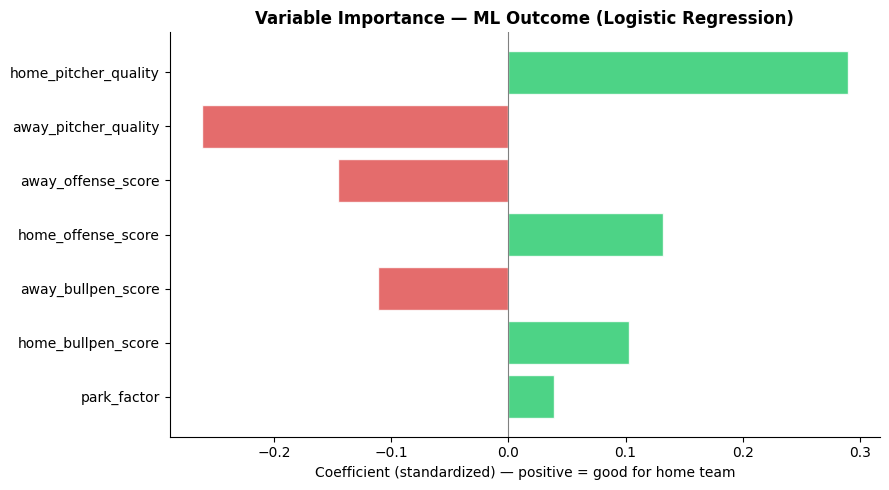

Logistic regression accuracy: 59.7%
Baseline (home team always wins): 52.5%

Coefficients (sorted by importance):
  home_pitcher_quality      +0.289  (+home)
  away_pitcher_quality      -0.261  (+away)
  away_offense_score        -0.146  (+away)
  home_offense_score        +0.132  (+home)
  away_bullpen_score        -0.111  (+away)
  home_bullpen_score        +0.103  (+home)
  park_factor               +0.039  (+home)


In [5]:
# ML outcome: which inputs predict whether the home team wins?
features = [
    'home_pitcher_quality', 'away_pitcher_quality',
    'home_offense_score',   'away_offense_score',
    'home_bullpen_score',   'away_bullpen_score',
    'park_factor',
]

ml_data = df[features + ['actual_winner']].dropna().copy()
ml_data['home_wins'] = (ml_data['actual_winner'] == 'home').astype(int)

X = ml_data[features]
y = ml_data['home_wins']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'feature':     features,
    'coefficient': lr.coef_[0],
    'abs_coef':    np.abs(lr.coef_[0])
}).sort_values('abs_coef', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2ecc71' if c > 0 else '#e05252' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Variable Importance — ML Outcome (Logistic Regression)', fontweight='bold')
ax.set_xlabel('Coefficient (standardized) — positive = good for home team')
plt.tight_layout()
plt.savefig('variable_importance_ml.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Logistic regression accuracy: {accuracy_score(y, lr.predict(X_scaled)):.1%}')
print(f'Baseline (home team always wins): {y.mean():.1%}')
print()
print('Coefficients (sorted by importance):')
for _, row in coef_df.sort_values('abs_coef', ascending=False).iterrows():
    direction = '+home' if row['coefficient'] > 0 else '+away'
    print(f'  {row["feature"]:<25} {row["coefficient"]:+.3f}  ({direction})')

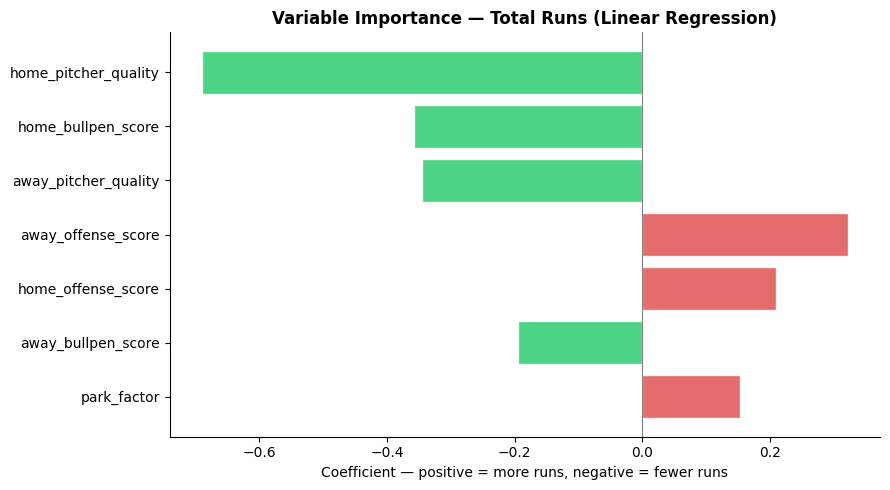

R²:   0.048  (0 = useless, 1 = perfect)
RMSE: 4.43 runs  (avg prediction error)
Mean actual total: 8.72 runs


In [6]:
# Total runs: which inputs predict actual run total?
total_data = df[features + ['actual_total']].dropna().copy()

X_t = total_data[features]
y_t = total_data['actual_total']

scaler_t = StandardScaler()
X_t_scaled = scaler_t.fit_transform(X_t)
lin = LinearRegression()
lin.fit(X_t_scaled, y_t)

coef_total = pd.DataFrame({
    'feature':     features,
    'coefficient': lin.coef_,
    'abs_coef':    np.abs(lin.coef_)
}).sort_values('abs_coef', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e05252' if c > 0 else '#2ecc71' for c in coef_total['coefficient']]
ax.barh(coef_total['feature'], coef_total['coefficient'], color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_title('Variable Importance — Total Runs (Linear Regression)', fontweight='bold')
ax.set_xlabel('Coefficient — positive = more runs, negative = fewer runs')
plt.tight_layout()
plt.savefig('variable_importance_total.png', dpi=150, bbox_inches='tight')
plt.show()

residuals = y_t - lin.predict(X_t_scaled)
print(f'R²:   {lin.score(X_t_scaled, y_t):.3f}  (0 = useless, 1 = perfect)')
print(f'RMSE: {np.sqrt((residuals**2).mean()):.2f} runs  (avg prediction error)')
print(f'Mean actual total: {y_t.mean():.2f} runs')

## 5. Does Bullpen Data Help?

In [7]:
import math

def win_prob_no_bp(row):
    hp = row['home_pitcher_quality']
    ap = row['away_pitcher_quality']
    ho = row['home_offense_score']
    ao = row['away_offense_score']
    pf = row['park_factor']
    home_runs = (9/2) - ap + ho * 2.0
    away_runs = (9/2) - hp + ao * 2.0
    home_runs *= pf
    away_runs *= pf * 0.95
    rd = home_runs - away_runs
    return min(0.75, max(0.30, 1/(1+math.exp(-rd*0.18)) + 0.025))

bp_data = df[features + ['actual_winner','ml_correct']].dropna().copy()
bp_data['actual_home'] = (bp_data['actual_winner'] == 'home').astype(int)
bp_data['pred_no_bp']  = (bp_data.apply(win_prob_no_bp, axis=1) >= 0.5).astype(int)

no_bp_acc   = accuracy_score(bp_data['actual_home'], bp_data['pred_no_bp'])
with_bp_acc = bp_data['ml_correct'].mean()

print(f'Model WITHOUT bullpen: {no_bp_acc:.1%}')
print(f'Model WITH bullpen:    {with_bp_acc:.1%}')
print(f'Bullpen contribution:  {(with_bp_acc - no_bp_acc)*100:+.1f} percentage points')

Model WITHOUT bullpen: 58.6%
Model WITH bullpen:    58.7%
Bullpen contribution:  +0.0 percentage points


## 6. Model vs Vegas — Total Runs

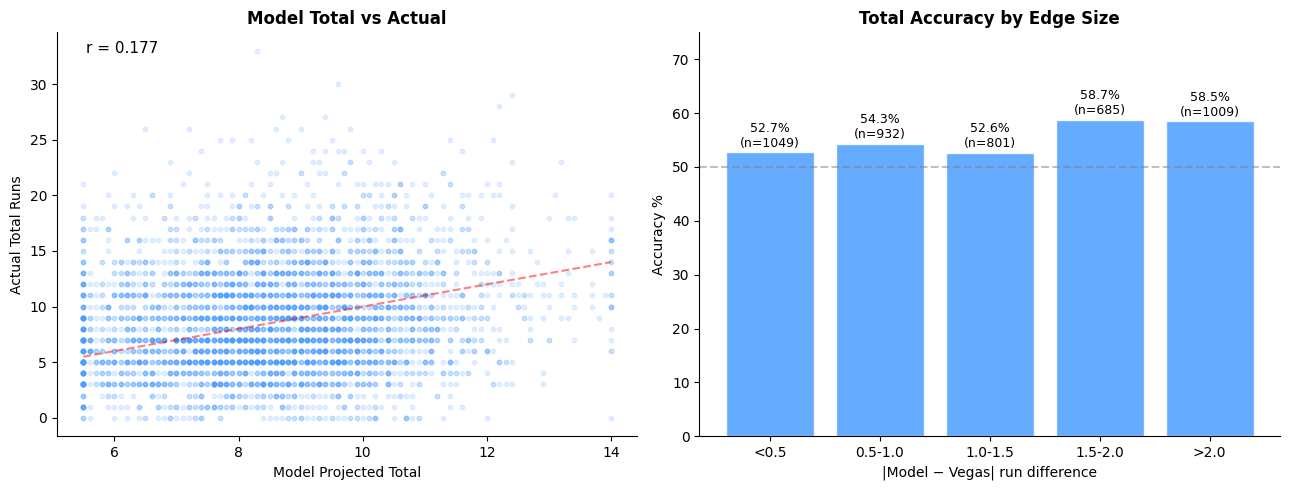

Correlation (model vs actual runs): r = 0.177
Total direction accuracy: 54.1%

Right chart: does larger model-Vegas gap = better accuracy?
If yes, big edges are real signal. If no, edges are noise.


In [8]:
tv = odds[odds['total_ou_result'].isin(['over','under'])].copy()
tv['total_correct'] = (tv['model_total_dir'] == tv['total_ou_result']).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Model total vs actual total
axes[0].scatter(tv['model_total'], tv['actual_total'], alpha=0.15, s=10, color='#4a9eff')
mn, mx = tv['model_total'].min(), tv['model_total'].max()
axes[0].plot([mn, mx], [mn, mx], 'r--', alpha=0.5, label='Perfect prediction')
axes[0].set_xlabel('Model Projected Total')
axes[0].set_ylabel('Actual Total Runs')
axes[0].set_title('Model Total vs Actual', fontweight='bold')
corr = tv[['model_total','actual_total']].corr().iloc[0,1]
axes[0].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[0].transAxes, fontsize=11)

# Total accuracy by model-vegas diff bucket
tv['diff_bucket'] = pd.cut(tv['total_diff'].abs(), bins=[0, 0.5, 1.0, 1.5, 2.0, 10],
                            labels=['<0.5', '0.5-1.0', '1.0-1.5', '1.5-2.0', '>2.0'])
bucket_acc = tv.groupby('diff_bucket')['total_correct'].agg(['mean','count'])
axes[1].bar(bucket_acc.index.astype(str), bucket_acc['mean'] * 100,
            color='#4a9eff', alpha=0.85, edgecolor='white')
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.5)
for i, (acc, n) in enumerate(zip(bucket_acc['mean'], bucket_acc['count'])):
    axes[1].text(i, acc*100 + 0.5, f'{acc:.1%}\n(n={n})', ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('|Model − Vegas| run difference')
axes[1].set_ylabel('Accuracy %')
axes[1].set_title('Total Accuracy by Edge Size', fontweight='bold')
axes[1].set_ylim(0, 75)

plt.tight_layout()
plt.savefig('total_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Correlation (model vs actual runs): r = {corr:.3f}')
print(f'Total direction accuracy: {tv["total_correct"].mean():.1%}')
print()
print('Right chart: does larger model-Vegas gap = better accuracy?')
print('If yes, big edges are real signal. If no, edges are noise.')

## 7. F5 Model — Predictions vs Actuals

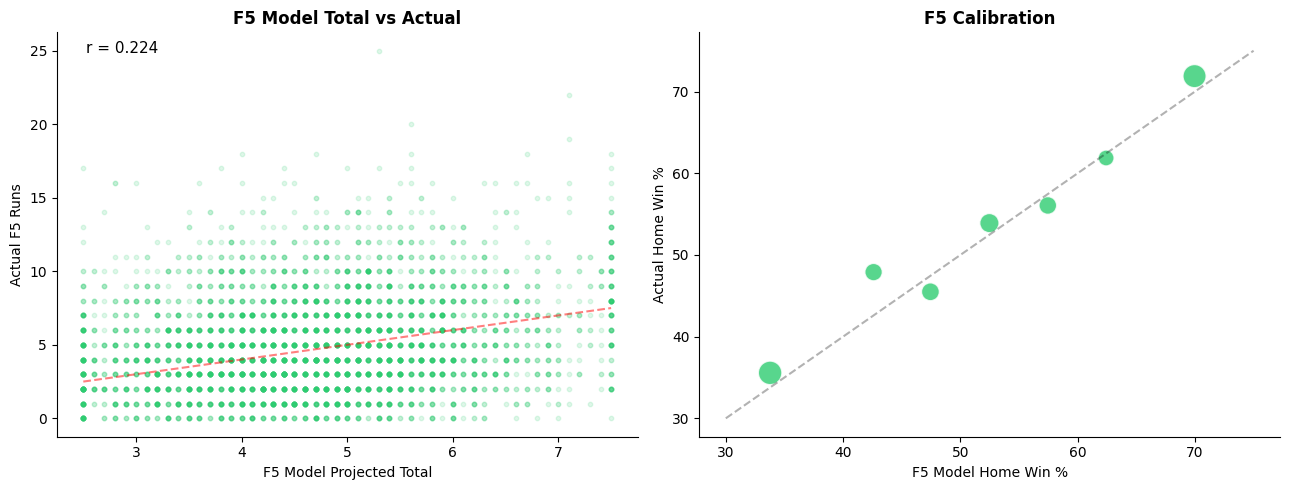

F5 total correlation (model vs actual): r = 0.224
Full game total correlation:            r = 0.177


In [9]:
f5 = df[df['f5_total_runs'] != ''].copy()
f5['f5_total_runs'] = pd.to_numeric(f5['f5_total_runs'], errors='coerce')
f5 = f5.dropna(subset=['f5_total_runs','f5_model_total'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(f5['f5_model_total'], f5['f5_total_runs'], alpha=0.15, s=10, color='#2ecc71')
mn, mx = f5['f5_model_total'].min(), f5['f5_model_total'].max()
axes[0].plot([mn, mx], [mn, mx], 'r--', alpha=0.5)
axes[0].set_xlabel('F5 Model Projected Total')
axes[0].set_ylabel('Actual F5 Runs')
axes[0].set_title('F5 Model Total vs Actual', fontweight='bold')
f5_corr = f5[['f5_model_total','f5_total_runs']].corr().iloc[0,1]
axes[0].text(0.05, 0.95, f'r = {f5_corr:.3f}', transform=axes[0].transAxes, fontsize=11)

# F5 ML calibration
f5_ml = f5[f5['f5_actual_winner'].isin(['home','away'])].copy()
f5_ml['prob_bin'] = pd.cut(f5_ml['f5_model_home_win_pct'],
                            bins=[30,40,45,50,55,60,65,75], right=False)
f5_cal = f5_ml.groupby('prob_bin').agg(
    actual=('f5_actual_winner', lambda x: (x=='home').mean()),
    n=('f5_actual_winner', 'count'),
    predicted=('f5_model_home_win_pct', 'mean')
).reset_index()
axes[1].plot([30,75],[30,75],'k--',alpha=0.3,label='Perfect')
axes[1].scatter(f5_cal['predicted'], f5_cal['actual']*100,
                s=f5_cal['n']/3, color='#2ecc71', alpha=0.8, edgecolors='white')
axes[1].set_xlabel('F5 Model Home Win %')
axes[1].set_ylabel('Actual Home Win %')
axes[1].set_title('F5 Calibration', fontweight='bold')

plt.tight_layout()
plt.savefig('f5_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'F5 total correlation (model vs actual): r = {f5_corr:.3f}')
print(f'Full game total correlation:            r = {corr:.3f}')

## 8. Theoretical ROI by Bet Type
If you bet $100 on every signal at the Vegas line, what happens?

In [10]:
def ml_payout(ml, won):
    """Return profit on $100 bet given ML odds and whether it won."""
    if pd.isna(ml): return None
    if won:
        return 100 if ml > 0 else 100 / (abs(ml)/100)
    return -100

results = {}

for tier in ['take', 'lean']:
    sub = odds[odds['ml_tier'] == tier].copy()
    sub = sub.dropna(subset=['vegas_home_ml','vegas_away_ml','actual_winner'])
    sub['model_fav_is_home'] = sub['model_home_win_pct'] >= 50
    sub['bet_ml']  = sub.apply(lambda r: r['vegas_home_ml'] if r['model_fav_is_home'] else r['vegas_away_ml'], axis=1)
    sub['bet_won'] = sub.apply(lambda r: (r['actual_winner'] == 'home') == r['model_fav_is_home'], axis=1)
    sub['profit'] = sub.apply(lambda r: ml_payout(r['bet_ml'], r['bet_won']), axis=1)
    sub = sub.dropna(subset=['profit'])
    total_profit = sub['profit'].sum()
    roi = total_profit / (len(sub) * 100) * 100
    results[f'ML {tier.title()}'] = {'n': len(sub), 'profit': total_profit, 'roi': roi, 'acc': sub['bet_won'].mean()}

# Total bets (standard -110 juice)
total_sub = odds[odds['total_ou_result'].isin(['over','under'])].copy()
total_sub['total_correct'] = (total_sub['model_total_dir'] == total_sub['total_ou_result']).astype(int)
for tier in ['take', 'lean']:
    sub = total_sub[total_sub['total_tier'].fillna('') == tier].copy()
    if len(sub) == 0: continue
    sub['bet_won'] = sub['total_correct'].astype(bool)
    sub['profit']  = sub.apply(lambda r: ml_payout(-110, r['bet_won']), axis=1)
    total_profit   = sub['profit'].sum()
    roi = total_profit / (len(sub) * 100) * 100
    results[f'Total {tier.title()}'] = {'n': len(sub), 'profit': total_profit, 'roi': roi, 'acc': sub['bet_won'].mean()}

print(f'{"Bet Type":<18} {"N":>6} {"Accuracy":>10} {"Total P/L":>12} {"ROI":>8}')
print('-' * 58)
for name, r in results.items():
    print(f'{name:<18} {r["n"]:>6,} {r["acc"]:>10.1%} {r["profit"]:>+12,.0f} {r["roi"]:>+7.1f}%')
print()
print('Note: ROI > 0% = profitable. Need ~52.4% accuracy at -110 to break even.')
print('Positive ROI on a large sample (n>200) is meaningful signal.')

Bet Type                N   Accuracy    Total P/L      ROI
----------------------------------------------------------
ML Take             1,027      59.4%       +7,749    +7.5%
ML Lean               809      57.7%         +571    +0.7%
Total Take          1,172      59.1%      +15,100   +12.9%
Total Lean            699      58.9%       +8,755   +12.5%

Note: ROI > 0% = profitable. Need ~52.4% accuracy at -110 to break even.
Positive ROI on a large sample (n>200) is meaningful signal.


## 9. Summary & Next Steps

In [11]:
print('══ Model Summary ══════════════════════════════')
print(f'Dataset:             {len(df):,} games  ({df["season"].unique()})')
print(f'Games with odds:     {df["has_odds"].sum():,}')
print()
print(f'ML accuracy:         {ml_acc:.1%}  (inflated — includes games model just follows Vegas)')
print(f'  Agrees w/ Vegas:   {agree_acc:.1%} ({agree_n:,} games)')
print(f'  Picks upset:       {disagree_acc:.1%} ({disagree_n:,} games)  ← real edge signal')
print(f'Total direction:     {total_correct:.1%}')
print(f'RL (model vs actual):{rl_acc:.1%}  (baseline: {rl_base:.1%} fav cover rate)')
print(f'F5 ML:               {f5_acc:.1%}')
print()
print(f'Brier score:         {brier:.4f}  (0.25 = random)')
print(f'Total corr:          r={corr:.3f} (full game) / r={f5_corr:.3f} (F5)')
print(f'Bullpen impact:      {(with_bp_acc - no_bp_acc)*100:+.1f} pp')
print()
print('── ROI Summary ────────────────────────────────')
for name, r in results.items():
    flag = '✓' if r['roi'] > 0 else '✗'
    print(f'{flag} {name:<16} {r["acc"]:.1%} acc  {r["roi"]:+.1f}% ROI  (n={r["n"]:,})')
print()
print('Next: Add rolling team offense, pitcher last-5-start form, weather')

══ Model Summary ══════════════════════════════
Dataset:             4,933 games  (<StringArray>
['2024', '2025']
Length: 2, dtype: str)
Games with odds:     4,763

ML accuracy:         58.8%  (inflated — includes games model just follows Vegas)
  Agrees w/ Vegas:   60.2% (3,621 games)
  Picks upset:       54.4% (1,139 games)  ← real edge signal
Total direction:     51.9%
RL (model vs actual):50.7%  (baseline: 41.3% fav cover rate)
F5 ML:               60.6%

Brier score:         0.2384  (0.25 = random)
Total corr:          r=0.177 (full game) / r=0.224 (F5)
Bullpen impact:      +0.0 pp

── ROI Summary ────────────────────────────────
✓ ML Take          59.4% acc  +7.5% ROI  (n=1,027)
✓ ML Lean          57.7% acc  +0.7% ROI  (n=809)
✓ Total Take       59.1% acc  +12.9% ROI  (n=1,172)
✓ Total Lean       58.9% acc  +12.5% ROI  (n=699)

Next: Add rolling team offense, pitcher last-5-start form, weather
